# Project FORESIGHT
## Forecasting Baseline

### Objective

Establish a simple seasonal-naive forecasting baseline for weekly SKU demand.

The baseline will:

- Load the cleaned weekly dataset
- Create a time-based train/test split
- Generate seasonal-naive forecasts
- Evaluate forecasts using WAPE
- Compare actual and predicted demand
- Save baseline predictions for later comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
ROOT_DIR = Path.cwd().parent

PROCESSED_DIR = ROOT_DIR / "data" / "processed"

df = pd.read_csv(
    PROCESSED_DIR / "analysis_ready_weekly.csv"
)

df["week_start"] = pd.to_datetime(df["week_start"])

df = df.sort_values(
    ["sku_id", "week_start"]
).reset_index(drop=True)

df.head()

,week_start,sku_id,units_sold,revenue,avg_price,promo_days,holiday_days,category,subcategory,launch_date,unit_cost,list_price,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2024-08-12,SKU_0001,15,224659.35,14977.29,0,1,Furniture,Desk,2024-08-12,6911.2,14977.29,53.0,0.0,5.0,17.0
1,2024-08-19,SKU_0001,10,149772.90,14977.29,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,27.0,0.0,5.0,17.0
2,2024-08-26,SKU_0001,14,209682.06,14977.29,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,4.0,37.0,5.0,17.0
3,2024-09-02,SKU_0001,10,149772.90,14977.29,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,37.0,0.0,5.0,17.0
4,2024-09-09,SKU_0001,16,239636.64,14977.29,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,7.0,37.0,5.0,17.0


## Time-Based Train/Test Split

Because this is a forecasting problem, observations must remain in chronological order.

We use the final 12 weeks as the test period and all earlier observations as training data.

In [3]:
forecast_horizon = 12

cutoff_date = (
    df["week_start"].max()
    - pd.Timedelta(weeks=forecast_horizon - 1)
)

train = df[
    df["week_start"] < cutoff_date
].copy()

test = df[
    df["week_start"] >= cutoff_date
].copy()

print("Training period:")
print(train["week_start"].min(), "to", train["week_start"].max())

print("\nTest period:")
print(test["week_start"].min(), "to", test["week_start"].max())

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

Training period:
2023-01-02 00:00:00 to 2025-10-06 00:00:00

Test period:
2025-10-13 00:00:00 to 2025-12-29 00:00:00

Train shape: (15672, 16)
Test shape: (2400, 16)


## Seasonal-Naive Forecast

For each SKU:

**Forecast(t) = Demand(t − 4 weeks)**

This provides a simple benchmark that incorporates short-term seasonal repetition.

The advanced forecasting model must outperform this baseline to demonstrate that the added modeling complexity is useful.

In [4]:
seasonal_period = 4

train_lookup = train.set_index(
    ["sku_id", "week_start"]
)["units_sold"]

test["forecast"] = test.apply(
    lambda row: train_lookup.get(
        (
            row["sku_id"],
            row["week_start"] - pd.Timedelta(
                weeks=seasonal_period
            )
        ),
        np.nan
    ),
    axis=1
)

test.head()

,week_start,sku_id,units_sold,revenue,avg_price,promo_days,holiday_days,category,subcategory,launch_date,unit_cost,list_price,on_hand_units,on_order_units,lead_time_days,reorder_point,forecast
61,2025-10-13,SKU_0001,16,239636.64,14977.290000,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,35.0,0.0,5.0,17.0,15.0
62,2025-10-20,SKU_0001,22,299471.57,13447.448571,7,0,Furniture,Desk,2024-08-12,6911.2,14977.29,24.0,0.0,5.0,17.0,23.0
63,2025-10-27,SKU_0001,26,330292.23,12864.862857,7,0,Furniture,Desk,2024-08-12,6911.2,14977.29,2.0,35.0,5.0,17.0,19.0
64,2025-11-03,SKU_0001,31,447086.99,14253.832857,3,0,Furniture,Desk,2024-08-12,6911.2,14977.29,35.0,0.0,5.0,17.0,19.0
65,2025-11-10,SKU_0001,26,389409.54,14977.290000,0,0,Furniture,Desk,2024-08-12,6911.2,14977.29,15.0,49.0,5.0,17.0,NaN


In [5]:
test = test.dropna(
    subset=["forecast"]
).copy()

test["forecast"] = test["forecast"].clip(
    lower=0
)

## Evaluation Metric — WAPE

Weighted Absolute Percentage Error (WAPE) measures total absolute forecast error relative to total actual demand.

Lower WAPE indicates better forecasting performance.

In [6]:
def wape(actual, forecast):
    denominator = np.abs(actual).sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(actual - forecast).sum()
        / denominator
    ) * 100


baseline_wape = wape(
    test["units_sold"],
    test["forecast"]
)

print(f"Baseline WAPE: {baseline_wape:.2f}%")

Baseline WAPE: 30.34%


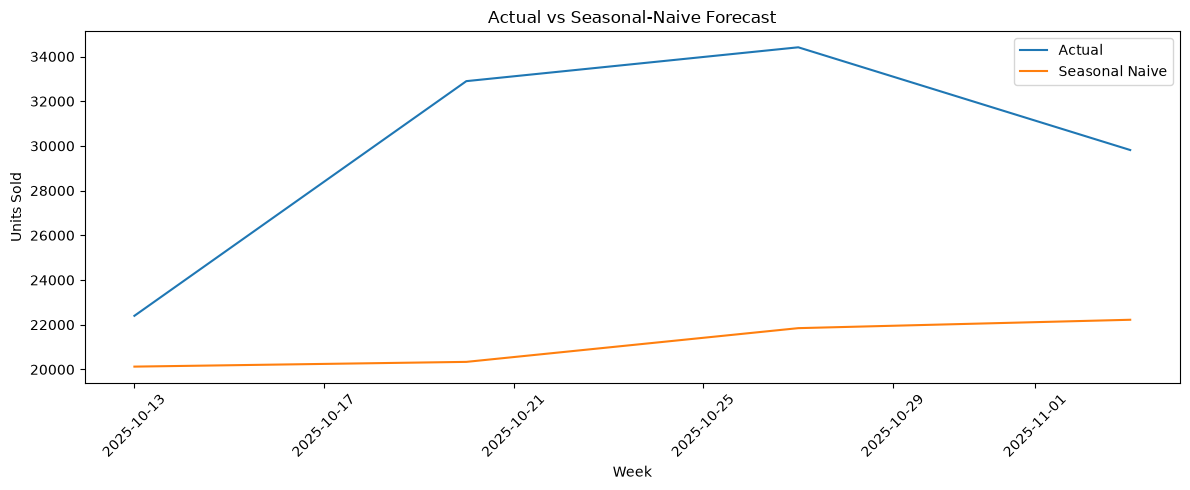

In [7]:
comparison = (
    test
    .groupby("week_start")[["units_sold", "forecast"]]
    .sum()
)

plt.figure(figsize=(12, 5))

plt.plot(
    comparison.index,
    comparison["units_sold"],
    label="Actual"
)

plt.plot(
    comparison.index,
    comparison["forecast"],
    label="Seasonal Naive"
)

plt.title("Actual vs Seasonal-Naive Forecast")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
sku_baseline = (
    test
    .groupby("sku_id")
    .apply(
        lambda x: wape(
            x["units_sold"],
            x["forecast"]
        ),
        include_groups=False
    )
    .reset_index(name="wape")
)

sku_baseline.sort_values(
    "wape"
).head(10)

,sku_id,wape
124,SKU_0125,13.392857
151,SKU_0152,15.909091
125,SKU_0126,16.042781
78,SKU_0079,16.906475
74,SKU_0075,17.808219
126,SKU_0127,18.297872
50,SKU_0051,19.686801
145,SKU_0146,20.080321
158,SKU_0159,20.192308
115,SKU_0116,20.645161


In [9]:
output_path = (
    PROCESSED_DIR
    / "baseline_predictions.csv"
)

test[
    [
        "week_start",
        "sku_id",
        "units_sold",
        "forecast"
    ]
].to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: c:\Users\saqib\Desktop\zidio\foresight-demand-inventory\data\processed\baseline_predictions.csv


# Baseline Conclusion

The seasonal-naive model establishes the forecasting benchmark for the project.

The resulting WAPE will be used as the reference point for evaluating the
advanced forecasting model in the next notebook.

The advanced model should improve upon this baseline while maintaining
appropriate time-series validation and avoiding future-data leakage.

### Output

- Baseline WAPE
- Actual vs forecast comparison
- SKU-level WAPE
- `baseline_predictions.csv`

### Next Step

Proceed to:

**03_forecasting_model.ipynb**